In [34]:
import pandas as pd
import numpy as np

In [35]:
# Data Loading 
df = pd.read_csv("./Data/data_1a.csv")
df.head

<bound method NDFrame.head of          AT      V       AP     RH      PE
0     14.96  41.76  1024.07  73.17  463.26
1     25.18  62.96  1020.04  59.08  444.37
2      5.11  39.40  1012.16  92.14  488.56
3     20.86  57.32  1010.24  76.64  446.48
4     10.82  37.50  1009.23  96.62  473.90
...     ...    ...      ...    ...     ...
9563  16.65  49.69  1014.01  91.00  460.03
9564  13.19  39.18  1023.67  66.78  469.62
9565  31.32  74.33  1012.92  36.48  429.57
9566  24.48  69.45  1013.86  62.39  435.74
9567  21.60  62.52  1017.23  67.87  453.28

[9568 rows x 5 columns]>

In [36]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [37]:
X = df.drop("PE", axis = 1)
y = df["PE"]

In [38]:
X.head()
y.head()

0    463.26
1    444.37
2    488.56
3    446.48
4    473.90
Name: PE, dtype: float64

In [39]:
# Split data into Training and Testing
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

df.shape

(9568, 5)

In [40]:
# Apply Standard Scaler
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
X_train_scaled

X_test_scaled

array([[ 0.00215965, -0.48812254,  0.26157687,  0.11048159],
       [ 1.16163808,  1.17765165, -0.04119705, -2.13662517],
       [ 1.12397521,  1.01555931, -0.99829906,  0.13304839],
       ...,
       [-1.56084956, -1.19786667,  0.88058134, -0.36068596],
       [ 0.92220982,  1.17056995, -0.66356567,  0.73619756],
       [-0.57623446,  1.32794115,  1.09925139,  0.28828066]])

In [41]:
# Convert into Tensor
import torch 
import torch.nn as nn
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1,1)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1,1)


In [42]:
# dataset and Dataloader
from torch.utils.data import TensorDataset, DataLoader

Train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
Test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(Train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(Test_dataset, batch_size=32)

In [43]:
# Make a ANN model
class ANN(nn.Module):
    def __init__(self):
        super(ANN,self).__init__()

        self.model = nn.Sequential(
            # 1st hidden Layer
            nn.Linear(X_train.shape[1], 6),
            nn.ReLU(),

            #2nd hidden Layer
            nn.Linear(6, 6),
            nn.ReLU(),

            #3rd hidden Layer
            nn.Linear(6, 6),
            nn.ReLU(),

            #Output Layer
            nn.Linear(6, 1),
        )
    def forward(self, x):
        return self.model(x)

In [44]:
# Loss, Optimizer 
import torch.optim as optim
model = ANN()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

In [46]:
# Train the ANN
train_losses = []
valid_losses = []

best_val_loss = float("inf")

epochs = 100

for epoch in range(epochs): 
    model.train()
    running_loss = 0.0   # total training loss in 1 epoch

    for xb,yb in train_loader:
        optimizer.zero_grad()  # fresh start gradient for each batch

        output = model(xb) 
        loss = criterion(output, yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()    # item() = convert tensor to  py float 

    epoch_training_loss = running_loss/len(train_loader)
    train_losses.append(epoch_training_loss)


    # Validation
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():
        for xb,yb in test_loader:
            
            output = model(xb)
            loss = criterion(output, yb)
            running_val_loss += loss

    epoch_val_loss = running_val_loss / len(test_loader)
    valid_losses.append(epoch_val_loss)


    print(f"epoch {epoch+1}/ {epochs} ==> Train_loss = {epoch_training_loss} && Val_loss = {epoch_val_loss}")

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), "best_model.pt") # .pth  or .pt

epoch 1/ 100 ==> Train_loss = 180094.41077473958 && Val_loss = 122746.3359375
epoch 2/ 100 ==> Train_loss = 54427.92596435547 && Val_loss = 21508.53125
epoch 3/ 100 ==> Train_loss = 16213.570536295572 && Val_loss = 12457.4755859375
epoch 4/ 100 ==> Train_loss = 9498.379395548503 && Val_loss = 7007.6767578125
epoch 5/ 100 ==> Train_loss = 5182.054692077637 && Val_loss = 3782.151611328125
epoch 6/ 100 ==> Train_loss = 2807.476586405436 && Val_loss = 2123.499755859375
epoch 7/ 100 ==> Train_loss = 1606.9647430419923 && Val_loss = 1270.500244140625
epoch 8/ 100 ==> Train_loss = 974.3506290435791 && Val_loss = 798.6665649414062
epoch 9/ 100 ==> Train_loss = 614.5380041758219 && Val_loss = 524.4210815429688
epoch 10/ 100 ==> Train_loss = 414.21550426483157 && Val_loss = 362.96099853515625
epoch 11/ 100 ==> Train_loss = 293.3501908620199 && Val_loss = 258.8132019042969
epoch 12/ 100 ==> Train_loss = 211.1680370012919 && Val_loss = 188.51768493652344
epoch 13/ 100 ==> Train_loss = 156.50339744

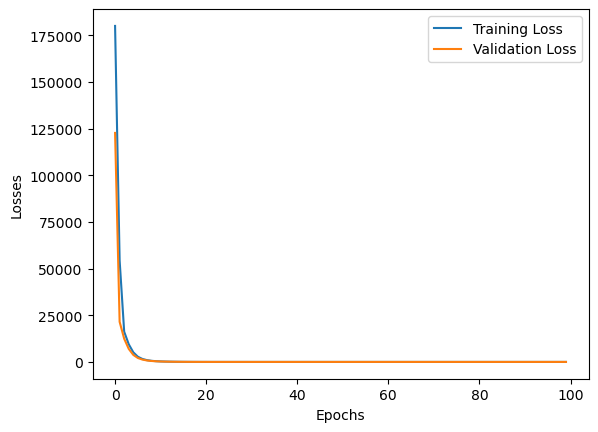

In [47]:
# plot the training losses
import pandas as pd
import matplotlib.pyplot as plt

loss_df = pd.DataFrame({
    "Training Loss": train_losses,
    "Validation Loss": valid_losses
})
plt.plot(loss_df["Training Loss"], label = "Training Loss")
plt.plot(loss_df["Validation Loss"], label = "Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")

plt.legend()

In [49]:
# Loading the best Model

model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

In [54]:
# Evaluate Our Model

model.eval()
with torch.no_grad():
    train_pred = model(X_train_tensor)
    test_pred = model(X_test_tensor)

    train_mse_loss = criterion(train_pred, y_train_tensor)
    test_mse_loss = criterion(test_pred, y_test_tensor)

print("Training MSE : ", train_mse_loss.item())
print("Testing MSE : ", test_mse_loss.item())
    

Training MSE :  20.3663387298584
Testing MSE :  19.75191879272461


In [55]:
# R2 Score
from sklearn.metrics import r2_score
print( "R2 = ", r2_score(y_test, test_pred))

R2 =  0.931903558859817
